В этом ноутбуке мы визуализируем удержание по когортам, строим heatmap для удержания на 7, 30, 90 день.
Также находим сезонные эффекты и аномалии (по типу праздников).

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

df_retention = pd.read_csv("processed_files/retention_table.csv")
df_retention.head()

,cohort_month,retention_upto_d7,retention_upto_d30,retention_upto_d90
0,2018-09,0.187,0.450,0.695
1,2018-10,0.153,0.381,0.628
2,2018-11,0.128,0.312,0.521
3,2018-12,0.121,0.266,0.458
4,2019-01,0.110,0.238,0.429


Переименовываем столбцы для heatmap

In [3]:
col_map = {
    "retention_upto_d7": "D7",
    "retention_upto_d30": "D30",
    "retention_upto_d90": "D90",
}
cols_present = [c for c in col_map.keys() if c in df_retention.columns]
if cols_present:
    df_plot = df_retention.rename(columns = col_map)
df_plot = df_plot.sort_values("cohort_month")
heat = df_plot.set_index("cohort_month")[["D7", "D30", "D90"]]
heat.head()

,D7,D30,D90
cohort_month,,,
2018-09,0.187,0.450,0.695
2018-10,0.153,0.381,0.628
2018-11,0.128,0.312,0.521
2018-12,0.121,0.266,0.458
2019-01,0.110,0.238,0.429


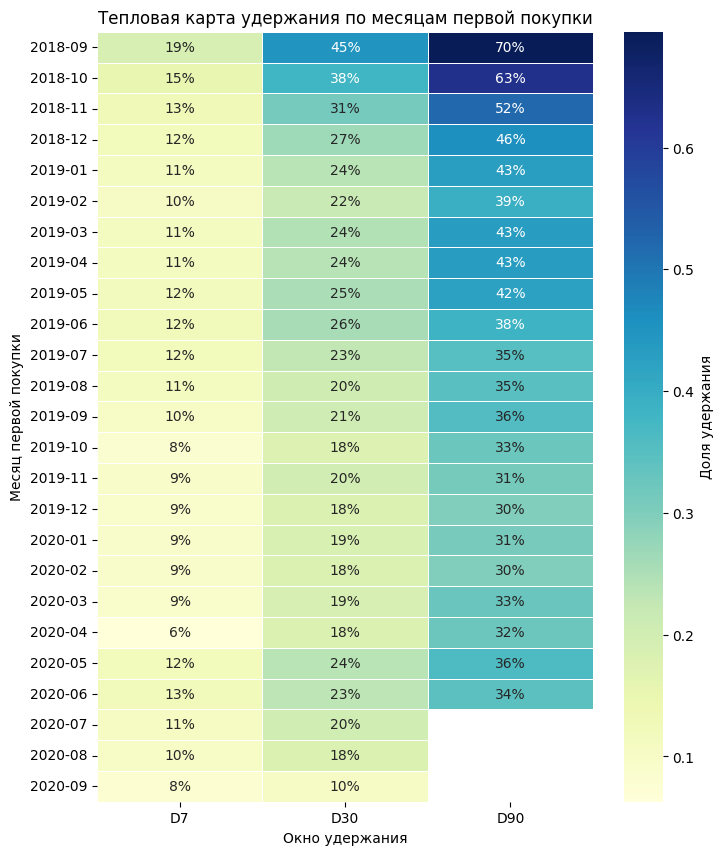

In [25]:
plt.figure(figsize=(8, 10))
sns.heatmap(
    heat,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    mask=heat.isna(),
    cbar_kws={"label": "Доля удержания"})
plt.title("Тепловая карта удержания по месяцам первой покупки")
plt.xlabel("Окно удержания")
plt.ylabel("Месяц первой покупки")
plt.show()

Тепловая карта удержания демонстрирует устойчивый нисходящий тренд. Например, в окне D30 в сентябре 2018 имеем 45% удержания. В сентябре 2019 - 21%. В сентябре же 2020 всего 10% удержания. Это может свидетельствовать о снижении качества привлечения клиентов или изменении покупательского поведения. 

С сентября 2018 по февраль 2019 удержание падает каждый месяц:
сентябрь(30-й день): 45%
октябрь: 38%
ноябрь: 31%
декабрь: 27%
январь: 24%
февраль: 22%
Это можно объяснить тем, что в декабре много разовых покупок (клиенты покупают подарки). В январе-феврале происходит постпраздничный спад, что характерно для ритейла.

Самый низкий процент удержания наблюдаем в апреле 2020. Это может быть связано с ковидом. Люди меньше выходят из дома, а значит меньше тратят и соответственно меняется их поведение.